# CatBoost scorecards

Upcoming addition to [**`xbooster`**](https://github.com/xRiskLab/xBooster) package.

Author: https://www.github.com/deburky

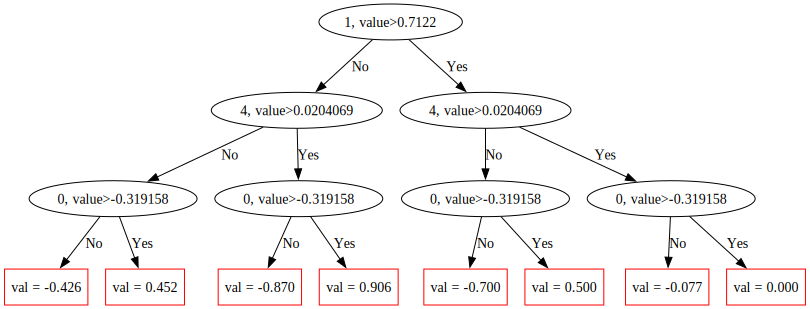

In [1]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.datasets import make_classification

# Step 1: Fit a CatBoost model
X, y = make_classification(n_samples=1000, n_features=5, random_state=42)
X = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
model = CatBoostClassifier(iterations=10, depth=3, verbose=0)
model.fit(X, y)
model.plot_tree(tree_idx=0)  # .render(filename='cb_tree', format='png')

In [2]:
import catboost as cb

# get available methods from cb_obj
cb_obj = model._object
tree_count = cb_obj._get_tree_count()
tree_leaf_count = cb_obj._get_tree_leaf_counts()
cb_depth = model.get_all_params()["depth"]
print(f"Tree count: {tree_count}")
print(f"Tree leaf count: {tree_leaf_count}")
print(f"Tree depth: {2**cb_depth}")

# Tree splits
pool = cb.Pool(X, y)
cb_obj._get_tree_splits(0, pool)

Tree count: 10
Tree leaf count: [8 8 8 8 8 8 8 8 8 8]
Tree depth: 8


['feature_0, bin=-0.319158',
 'feature_4, bin=0.0204069',
 'feature_1, bin=0.7122']

## Scorecard from splits

In [3]:
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.datasets import make_classification
from catboost_scorecard import CatBoostScorecard

# Prepare data
X, y = make_classification(
    n_samples=1000, n_features=5, random_state=42, weights=[0.9, 0.1]
)
pool = Pool(X, y)

# Fit model
model = CatBoostClassifier(iterations=10, depth=3, verbose=0, learning_rate=1.0)
model.fit(pool)

# Run scorecard extraction
scorecard = CatBoostScorecard.trees_to_scorecard(model, pool)

tree_idx = 5
print(len(scorecard.query("Tree == @tree_idx")))
display(scorecard.query("Tree == @tree_idx"))

8


,Tree,LeafIndex,Conditions,Count,NonEvents,Events,EventRate,LeafValue,WOE
40,5,0,1 <= -0.729589 AND 1 <= 0.539797 AND 0 <= -0.3...,13.0,13.0,0.0,0.000000,-0.435,-4.763891
41,5,1,1 <= -0.729589 AND 1 <= 0.539797 AND 0 > -0.39...,33.0,2.0,31.0,0.939394,0.457,4.883703
42,5,2,1 <= -0.729589 AND 1 > 0.539797 AND 0 <= -0.39...,0.0,0.0,0.0,0.105000,0.000,0.000000
43,5,3,1 <= -0.729589 AND 1 > 0.539797 AND 0 > -0.396464,0.0,0.0,0.0,0.105000,0.000,0.000000
44,5,4,1 > -0.729589 AND 1 <= 0.539797 AND 0 <= -0.39...,377.0,370.0,7.0,0.018568,-0.241,-1.824729
45,5,5,1 > -0.729589 AND 1 <= 0.539797 AND 0 > -0.396464,198.0,146.0,52.0,0.262626,0.127,1.110500
46,5,6,1 > -0.729589 AND 1 > 0.539797 AND 0 <= -0.396464,371.0,363.0,8.0,0.021563,-0.006,-1.672098
47,5,7,1 > -0.729589 AND 1 > 0.539797 AND 0 > -0.396464,8.0,1.0,7.0,0.875000,0.566,4.088774


In [4]:
df = scorecard.query("Tree == @tree_idx").copy()
df["avg"] = y.mean()
df["diff"] = df["avg"] - df["EventRate"]
correlation_event_rate = df[["LeafValue", "diff"]].corr(method="spearman").values[0, 1]
print(f"Spearman correlation (EventRate): {correlation_event_rate:.4f}")
df[["LeafValue", "diff", "EventRate"]]

correlation_woe = df[["LeafValue", "WOE"]].corr(method="spearman").values[0, 1]
print(f"Spearman correlation (WOE): {correlation_woe:.4f}")

Spearman correlation (EventRate): -0.9759
Spearman correlation (WOE): 0.9759


In [5]:
from sklearn.linear_model import LinearRegression

x, target = df[["WOE"]], df["LeafValue"]
lr_model = LinearRegression()
lr_model.fit(x, target)
print(f"Intercept: {lr_model.intercept_:.4f}")
print(f"Coefficient: {lr_model.coef_[0]:.4f}")

r2 = lr_model.score(x, target)
print(f"R^2: {r2:.4f}")

Intercept: 0.0355
Coefficient: 0.1012
R^2: 0.9389


,Tree,LeafIndex,Conditions,Count,NonEvents,Events,EventRate,LeafValue,WOE
40,5,0,1 <= -0.729589 AND 1 <= 0.539797 AND 0 <= -0.3...,13.0,13.0,0.0,0.000000,-0.435,-4.763891
41,5,1,1 <= -0.729589 AND 1 <= 0.539797 AND 0 > -0.39...,33.0,2.0,31.0,0.939394,0.457,4.883703
42,5,2,1 <= -0.729589 AND 1 > 0.539797 AND 0 <= -0.39...,0.0,0.0,0.0,0.105000,0.000,0.000000
43,5,3,1 <= -0.729589 AND 1 > 0.539797 AND 0 > -0.396464,0.0,0.0,0.0,0.105000,0.000,0.000000
44,5,4,1 > -0.729589 AND 1 <= 0.539797 AND 0 <= -0.39...,377.0,370.0,7.0,0.018568,-0.241,-1.824729
45,5,5,1 > -0.729589 AND 1 <= 0.539797 AND 0 > -0.396464,198.0,146.0,52.0,0.262626,0.127,1.110500
46,5,6,1 > -0.729589 AND 1 > 0.539797 AND 0 <= -0.396464,371.0,363.0,8.0,0.021563,-0.006,-1.672098
47,5,7,1 > -0.729589 AND 1 > 0.539797 AND 0 > -0.396464,8.0,1.0,7.0,0.875000,0.566,4.088774


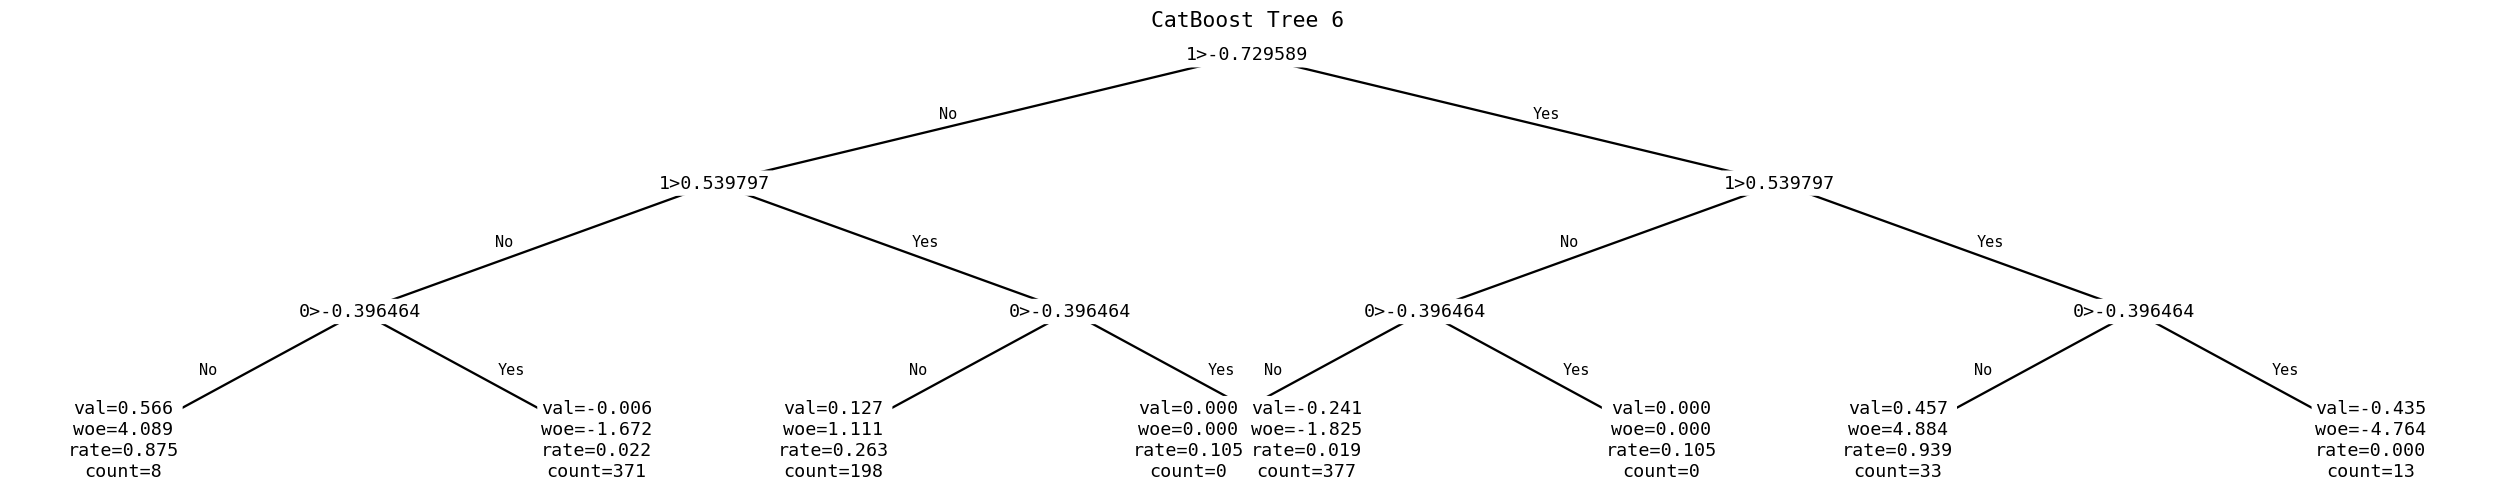

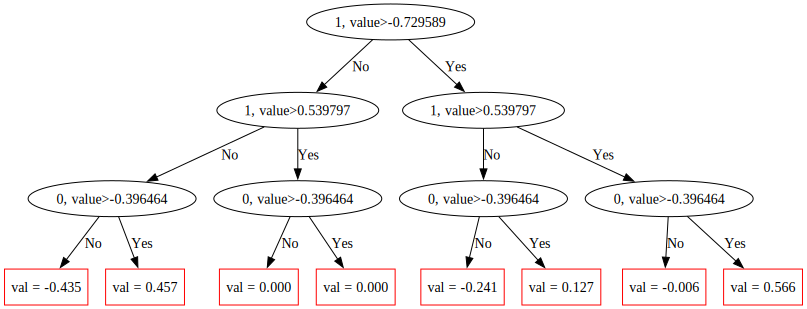

In [6]:
from utils import CatBoostTreeVisualizer

display(scorecard.query("Tree == @tree_idx"))
visualizer = CatBoostTreeVisualizer(scorecard)
visualizer.plot_tree(tree_idx=tree_idx)
model.plot_tree(tree_idx=tree_idx)

## Categorical features
### Focus on clean, interpretable split rules

Unique values after preprocessing: 3949
Contains '__other__': True
Time taken: 0.01 seconds
Tree 0 has 4 leaves


,Tree,LeafIndex,Conditions,Count,NonEvents,Events,EventRate,LeafValue,WOE
0,0,0,high_card_cat != 'cat_2646' AND high_card_cat != 'cat_16650',4998.0,2500.0,2498.0,0.4998,-0.000,-3.201281e-07
1,0,1,high_card_cat != 'cat_2646' AND high_card_cat = 'cat_16650',1.0,1.0,0.0,0.0000,-0.015,-6.905955e+00
2,0,2,high_card_cat = 'cat_2646' AND high_card_cat != 'cat_16650',1.0,0.0,1.0,1.0000,0.015,6.907555e+00
3,0,3,high_card_cat = 'cat_2646' AND high_card_cat = 'cat_16650',0.0,0.0,0.0,0.4998,0.000,0.000000e+00


7.3 kB


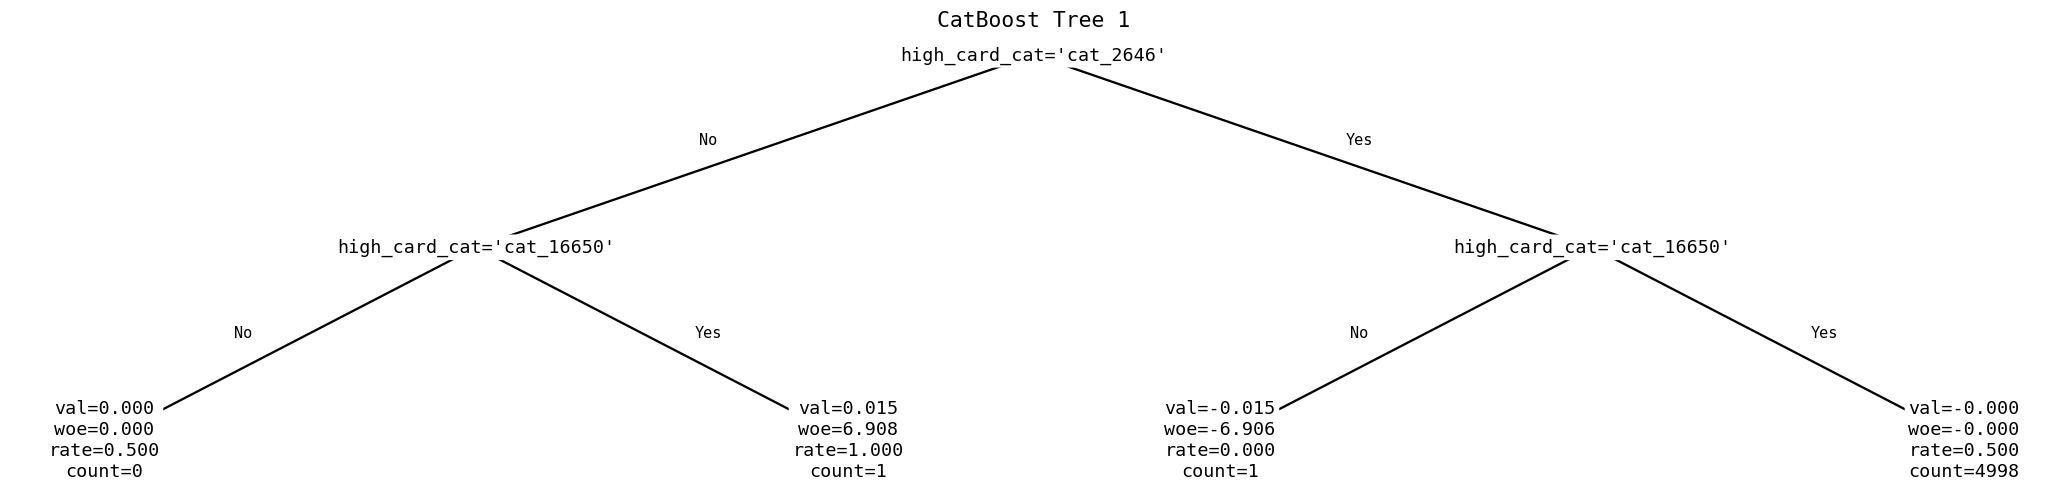

lib/pathplan/shortest.c:334: triangulation failed
lib/pathplan/shortest.c:204: cannot find triangle path
lib/pathplan/shortest.c:334: triangulation failed
lib/pathplan/shortest.c:204: cannot find triangle path


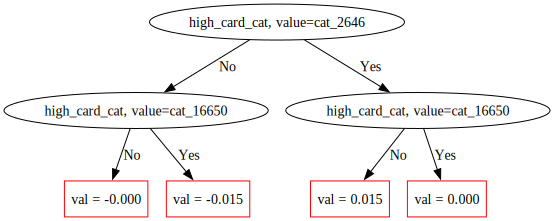

In [7]:
import time

import numpy as np
import humanize
import catboost as cb
import pandas as pd
from utils import CatBoostPreprocessor
from catboost_scorecard import CatBoostScorecard
from utils import CatBoostTreeVisualizer

pd.set_option("display.max_colwidth", 100)

# High cardinal data
n_samples = 5_000
n_categories = 20_000

# Generate synthetic data
df = pd.DataFrame(
    {
        "high_card_cat": np.random.choice(
            [f"cat_{i}" for i in range(n_categories)], size=n_samples
        ),
        "target": np.random.randint(0, 2, size=n_samples),
    }
)

cat_feature = "high_card_cat"

# Apply the preprocessor (reduce to top 50 categories)
preproc = CatBoostPreprocessor()
df_processed = preproc.fit_transform(df, cat_features=[cat_feature])

# Confirm preprocessing worked
print(f"Unique values after preprocessing: {df_processed[cat_feature].nunique()}")
print(f"Contains '__other__': {'__other__' in df_processed[cat_feature].unique()}")

# Train CatBoost
pool = cb.Pool(
    data=df_processed[[cat_feature]],
    label=df_processed["target"],
    cat_features=[cat_feature],
)

model = cb.CatBoostClassifier(
    iterations=10,
    allow_writing_files=False,
    depth=2,
    learning_rate=0.1,
    verbose=0,
    one_hot_max_size=9999,
    cat_features=[cat_feature],
)
model.fit(pool)

# Extract scorecard
output_format = "pandas"

time_start = time.time()
scorecard = CatBoostScorecard.trees_to_scorecard(
    model, pool, output_format=output_format
)
time_end = time.time()
print(f"Time taken: {time_end - time_start:.2f} seconds")

# # Show a tree's scorecard
tree_idx = 0
if output_format == "arrow":
    scorecard = scorecard.to_pandas()
print(f"Tree {tree_idx} has {len(scorecard.query('Tree == @tree_idx'))} leaves")
display(scorecard.query("Tree == @tree_idx").head())

try:
    print(humanize.naturalsize(scorecard.nbytes))
except AttributeError:
    size_bytes = scorecard.memory_usage(deep=True).sum()
    print(humanize.naturalsize(size_bytes))


visualizer = CatBoostTreeVisualizer(scorecard)
visualizer.plot_tree(tree_idx=tree_idx)

model.plot_tree(
    tree_idx=tree_idx,
    pool=pool,
)

## Text features
### Not yet interpretable

In [8]:
import numpy as np
import catboost as cb
from faker import Faker
import pandas as pd
from catboost_scorecard import CatBoostScorecard

fake_text = Faker()

X_df = pd.DataFrame(
    {
        "numerical_1": np.random.randn(1000),
        "numerical_2": np.random.randn(1000),
        "product_type": np.random.choice(["book", "movie", "music"], size=1000),
        "country": np.random.choice(["US", "UK", "JP"], size=1000),
        "description": [fake_text.text() * 100 for _ in range(1000)],
    }
)

y = np.random.randint(0, 2, size=1000)

# Define categorical features (including text)
cat_features = ["product_type", "country", "description"]

# Create Pool and train model
pool = cb.Pool(X_df, y, cat_features=cat_features, text_features=["description"])
model = cb.CatBoostClassifier(iterations=10, depth=3, verbose=0)
model.fit(pool)

# Generate scorecard
scorecard = CatBoostScorecard.trees_to_scorecard(model, pool)


# Show sample conditions
tree_idx = 0
display(scorecard.query("Tree == @tree_idx").head())

,Tree,LeafIndex,Conditions,Count,NonEvents,Events,EventRate,LeafValue,WOE
0,0,0,src_feature_id=0 calcer_id=CC1B134C2757991B056F1B3030A3FCF4 local_id=3 <= 0.5 AND src_feature_id...,971.0,491.0,480.0,0.494336,-0.011,0.009345
1,0,1,src_feature_id=0 calcer_id=CC1B134C2757991B056F1B3030A3FCF4 local_id=3 <= 0.5 AND src_feature_id...,18.0,14.0,4.0,0.222222,-0.333,-1.220760
2,0,2,src_feature_id=0 calcer_id=CC1B134C2757991B056F1B3030A3FCF4 local_id=3 <= 0.5 AND src_feature_id...,9.0,2.0,7.0,0.777778,0.238,1.284766
3,0,3,src_feature_id=0 calcer_id=CC1B134C2757991B056F1B3030A3FCF4 local_id=3 <= 0.5 AND src_feature_id...,1.0,0.0,1.0,1.000000,0.077,6.938758
4,0,4,src_feature_id=0 calcer_id=CC1B134C2757991B056F1B3030A3FCF4 local_id=3 > 0.5 AND src_feature_id=...,1.0,1.0,0.0,0.000000,-0.077,-6.874752


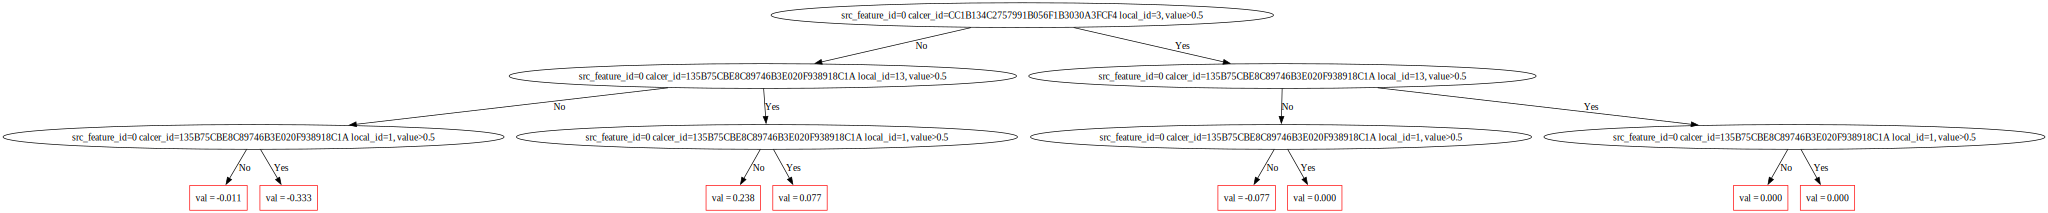

In [9]:
model.plot_tree(
    tree_idx=tree_idx,
    pool=pool,
)